In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("Agri Market Dataset.csv")
df.head()


,State Name,District Name,Market Name,Commodity,Variety,Group,Arrivals (Tonnes),Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Reported Date
0,Maharashtra,Amarawati,Achalpur,Arhar (Tur/Red Gram)(Whole),Other,Pulses,0.1,9800,10200,10000,11/12/2024
1,Maharashtra,Amarawati,Achalpur,Arhar (Tur/Red Gram)(Whole),Other,Pulses,0.3,10000,10550,10275,9/27/2024
2,Maharashtra,Amarawati,Achalpur,Arhar (Tur/Red Gram)(Whole),Other,Pulses,0.9,9000,10200,9600,10/25/2024
3,Maharashtra,Amarawati,Achalpur,Arhar (Tur/Red Gram)(Whole),Other,Pulses,1,4900,5450,5175,7/1/2020
4,Maharashtra,Amarawati,Achalpur,Arhar (Tur/Red Gram)(Whole),Other,Pulses,1,5000,5500,5250,7/7/2020


In [3]:
# Step 2: Basic Information
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)


Shape of dataset: (39060, 11)

Column names:
 ['State Name', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Group', 'Arrivals (Tonnes)', 'Min Price (Rs./Quintal)', 'Max Price (Rs./Quintal)', 'Modal Price (Rs./Quintal)', 'Reported Date']

Data types:

State Name                   object
District Name                object
Market Name                  object
Commodity                    object
Variety                      object
Group                        object
Arrivals (Tonnes)            object
Min Price (Rs./Quintal)       int64
Max Price (Rs./Quintal)       int64
Modal Price (Rs./Quintal)     int64
Reported Date                object
dtype: object


In [4]:
# Step 3: Missing Values and Duplicates
print("Missing Values:\n", df.isnull().sum())
print("\nTotal Duplicates:", df.duplicated().sum())

# Drop duplicates if needed
df = df.drop_duplicates()


Missing Values:
 State Name                   0
District Name                0
Market Name                  0
Commodity                    0
Variety                      0
Group                        0
Arrivals (Tonnes)            0
Min Price (Rs./Quintal)      0
Max Price (Rs./Quintal)      0
Modal Price (Rs./Quintal)    0
Reported Date                0
dtype: int64

Total Duplicates: 0


In [6]:
# Step 4: Summary Statistics
df.describe()


,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal)
count,39060.000000,39060.000000,39060.000000
mean,4514.067256,5137.418715,4891.901459
std,2384.768000,2735.345210,2550.162502
min,2.000000,3.000000,3.000000
25%,2300.000000,2600.000000,2475.000000
50%,4370.000000,4940.000000,4725.000000
75%,5960.000000,6600.000000,6300.000000
max,12100.000000,106600.000000,12720.000000


In [8]:
# Step 5: Handle Missing Values (Simple)
# Numeric columns: fill with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Object columns: fill with mode
for col in df.select_dtypes('object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])



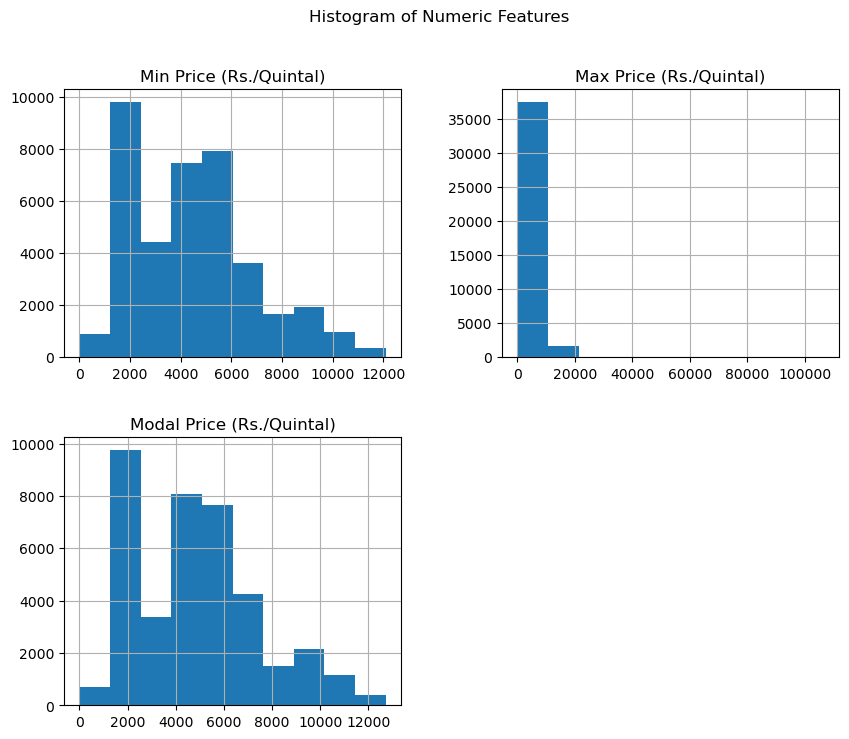

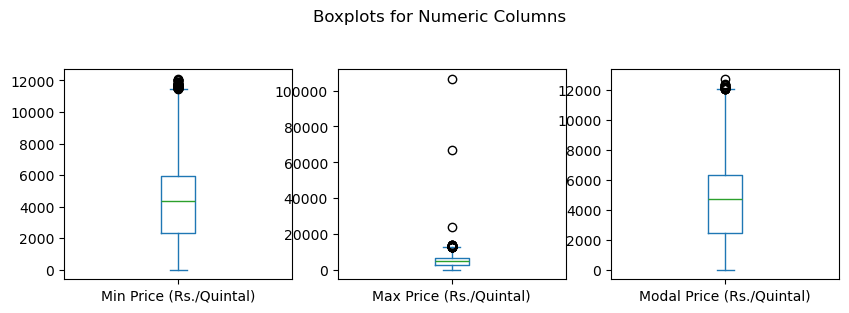

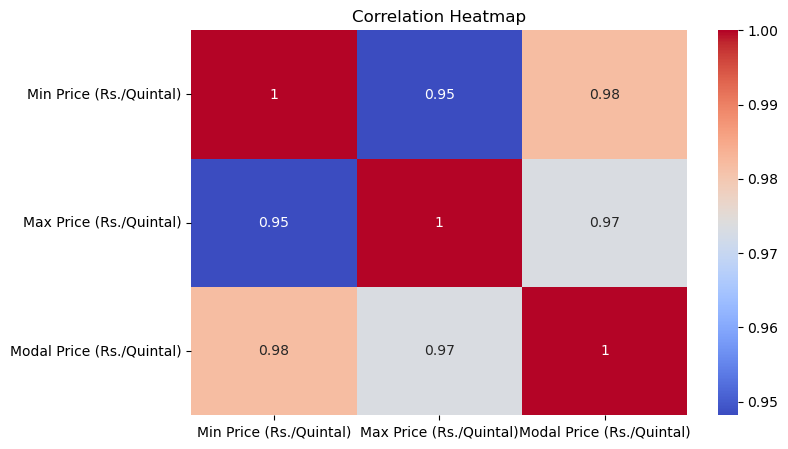

In [9]:
# Step 6: Data Visualization

# 1. Histogram for numeric columns
df.hist(figsize=(10,8))
plt.suptitle("Histogram of Numeric Features")
plt.show()

# 2. Boxplot to see outliers
df.plot(kind='box', subplots=True, layout=(2,3), figsize=(10,6), sharex=False, sharey=False)
plt.suptitle("Boxplots for Numeric Columns")
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


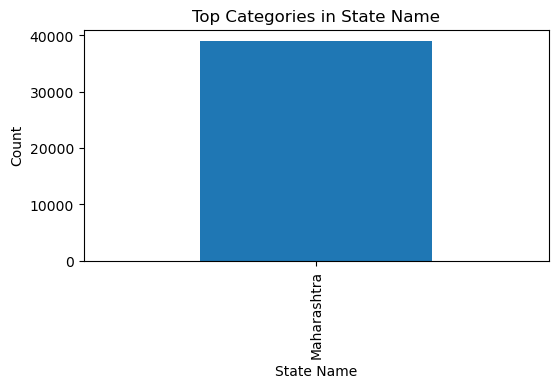

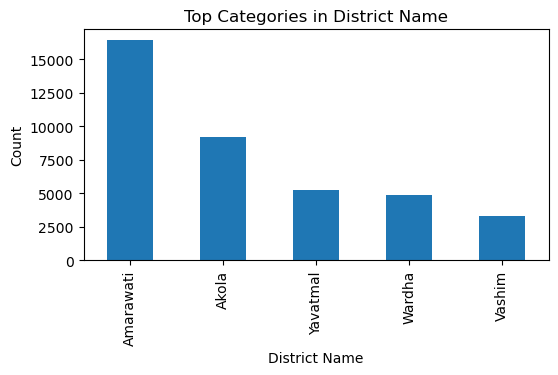

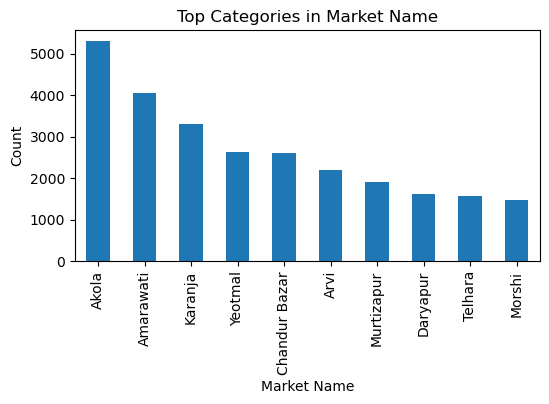

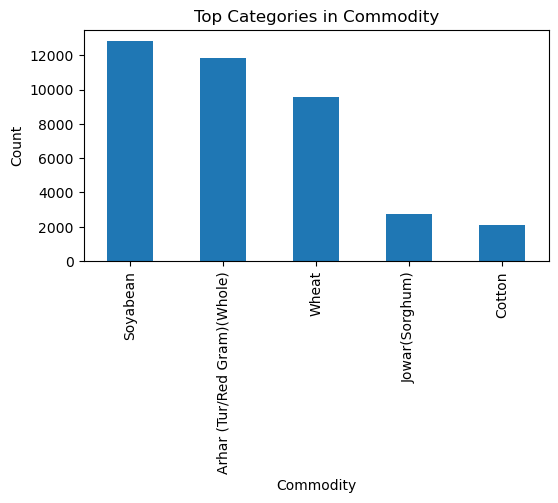

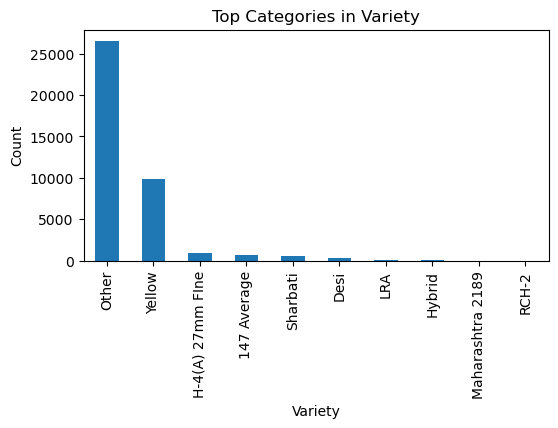

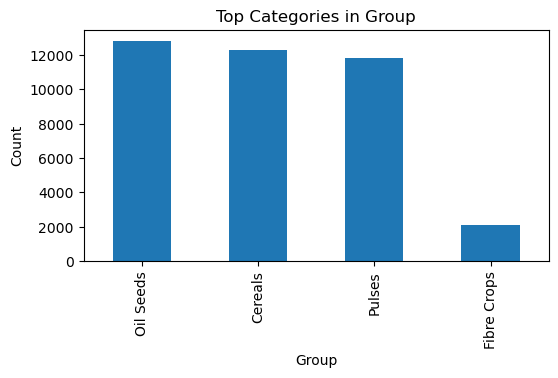

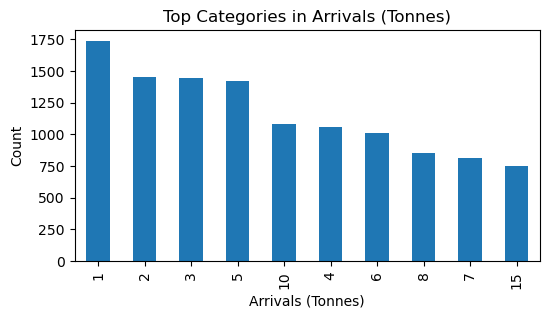

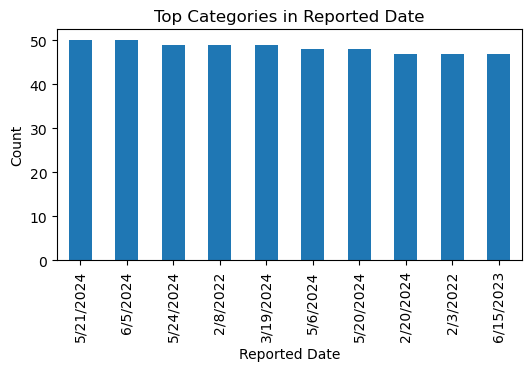

In [10]:
# Step 7: Categorical Column Analysis
for col in df.select_dtypes('object').columns:
    plt.figure(figsize=(6,3))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [11]:
# Step 8: Save Cleaned Dataset
df.to_csv("Cleaned_Agri_Market.csv", index=False)
print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!
